In [14]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Path to src_Jeffery.py
src_path = Path("../Pysimulations").resolve()

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

import src_Jeffery as jf

import tomli
from pathlib import Path

parameter_file = Path("parameters.toml")

with open(parameter_file, "rb") as f:
    params = tomli.load(f)

# PARTICLE PARAMETERS

Length = params["particle"]["length"]
diameter = params["particle"]["diameter"]

swimming_speed = params["particle"]["swimming_speed"]

eta = params["particle"]["eta"]

n_particle = params["particle"]["n_particle"]
n_medium = params["particle"]["n_medium"]


# INITIAL CONDITIONS

R0 = np.array([
    params["initial"]["x0"],
    params["initial"]["y0"],
    params["initial"]["z0"]
], dtype=float)

theta0_deg = params["initial"]["theta0_deg"]
phi0_deg = params["initial"]["phi0_deg"]


# FLOW PARAMETERS

gamma = params["flow"]["gamma"]
plane = params["flow"]["plane"]


# OPTICAL PARAMETERS

wavelength = params["optics"]["wavelength"]
w0 = params["optics"]["w0"]
laser_power = params["optics"]["laser_power"]

beam_axis = np.array(
    params["optics"]["beam_axis"],
    dtype=float
)

e_pol = np.array(
    params["optics"]["polarization"],
    dtype=float
)


# SIMULATION PARAMETERS

t0 = params["simulation"]["t0"]
tf = params["simulation"]["tf"]
n_points = params["simulation"]["n_points"]
rtol = params["simulation"]["rtol"]
atol = params["simulation"]["atol"]



print("PARTICLE")
print("Length =", Length, "m")
print("diameter =", diameter, "m")
print("swimming_speed =", swimming_speed, "m/s")
print("eta =", eta, "Pa s")
print("n_particle =", n_particle)
print("n_medium =", n_medium)

print()

print("INITIAL CONDITIONS")
print("R0 =", R0, "m")
print("theta0 =", theta0_deg, "deg")
print("phi0 =", phi0_deg, "deg")

print()

print("FLOW")
print("gamma =", gamma, "1/s")
print("plane =", plane)

print()

print("OPTICS")
print("wavelength =", wavelength, "m")
print("w0 =", w0, "m")
print("laser_power =", laser_power, "W")
print("beam_axis =", beam_axis)
print("polarization =", e_pol)



print()

print("SIMULATION")
print("t0 =", t0, "s")
print("tf =", tf, "s")
print("n_points =", n_points)

PARTICLE
Length = 5e-05 m
diameter = 7e-06 m
swimming_speed = 1e-05 m/s
eta = 0.000953 Pa s
n_particle = 1.38
n_medium = 1.33

INITIAL CONDITIONS
R0 = [0. 0. 0.] m
theta0 = 25.0 deg
phi0 = 25.0 deg

FLOW
gamma = 1 1/s
plane = xz

OPTICS
wavelength = 1.31e-06 m
w0 = 1.9e-06 m
laser_power = 0.025 W
beam_axis = [0. 0. 1.]
polarization = [0. 1. 0.]

SIMULATION
t0 = 0.0 s
tf = 500.0 s
n_points = 4000


In [15]:
# ============================================================
# PARTICLE GEOMETRY
# ============================================================

aspect_ratio = Length / diameter

beta = jf.lambda_ar(
    aspect_ratio
)

print("Aspect ratio =", aspect_ratio)
print("Bretherton parameter beta =", beta)

Aspect ratio = 7.142857142857143
Bretherton parameter beta = 0.9615535504119262


In [16]:
# ============================================================
# INITIAL ORIENTATION
# ============================================================

theta0 = np.deg2rad(
    theta0_deg
)

phi0 = np.deg2rad(
    phi0_deg
)

p0 = jf.sph_to_vec(
    theta0,
    phi0
)

print("theta0 =", theta0_deg, "deg")
print("phi0 =", phi0_deg, "deg")
print("p0 =", p0)
print("|p0| =", np.linalg.norm(p0))

theta0 = 25.0 deg
phi0 = 25.0 deg
p0 = [0.38302222 0.1786062  0.90630779]
|p0| = 1.0


In [17]:
# ============================================================
# SIMPLE SHEAR FLOW
# ============================================================

G = jf.grad_u_simple_shear(
    gamma=gamma,
    plane=plane
)

E, W = jf.decompose_grad_u(
    G
)

print("Velocity-gradient tensor G =")
print(G)

print()
print("Rate-of-strain tensor E =")
print(E)

print()
print("Rotation tensor W =")
print(W)

Velocity-gradient tensor G =
[[0. 0. 1.]
 [0. 0. 0.]
 [0. 0. 0.]]

Rate-of-strain tensor E =
[[0.  0.  0.5]
 [0.  0.  0. ]
 [0.5 0.  0. ]]

Rotation tensor W =
[[ 0.   0.   0.5]
 [ 0.   0.   0. ]
 [-0.5  0.   0. ]]


In [18]:
# ============================================================
# JEFFERY EQUATION
# ============================================================

t_eval = np.linspace(t0,tf,n_points)

sol_jeffery = solve_ivp(
    fun=lambda t, p: jf.jeffery_rhs_vector(t,p,E,W,beta),
    t_span=(t0, tf),
    y0=p0,
    t_eval=t_eval,
    rtol=rtol,
    atol=atol
)

if not sol_jeffery.success:
    raise RuntimeError(
        sol_jeffery.message
    )

In [19]:
P_raw = sol_jeffery.y.T

norm_raw = np.linalg.norm(P_raw,axis=1)

P = jf.normalize_rows(P_raw)
p0_sim = P[0]
pf = P[-1]

px = P[:, 0]
py = P[:, 1]
pz = P[:, 2]

print("Initial director =", p0_sim)
print("Final director =", pf)

print(
    "Maximum norm error =",
    np.max(np.abs(norm_raw - 1.0))
)

Initial director = [0.38302222 0.1786062  0.90630779]
Final director = [-0.94759665  0.06677156  0.31241343]
Maximum norm error = 7.51962239142756e-08


In [20]:
# ============================================================
# ORIENTATION ANGLES
# ============================================================

theta_rad, phi_wrapped, phi_unwrapped = (
    jf.directors_to_angles(P)
)

theta_deg = np.rad2deg(
    theta_rad
)

phi_deg = np.rad2deg(
    phi_unwrapped
)

print(
    "Initial theta =",
    theta_deg[0],
    "deg"
)

print(
    "Initial phi =",
    phi_deg[0],
    "deg"
)

print()
print(
    "Final theta =",
    theta_deg[-1],
    "deg"
)

print(
    "Final phi =",
    phi_deg[-1],
    "deg"
)

Initial theta = 25.000000000000004 deg
Initial phi = 25.000000000000004 deg

Final theta = 71.79526436660647 deg
Final phi = 175.96936548379057 deg


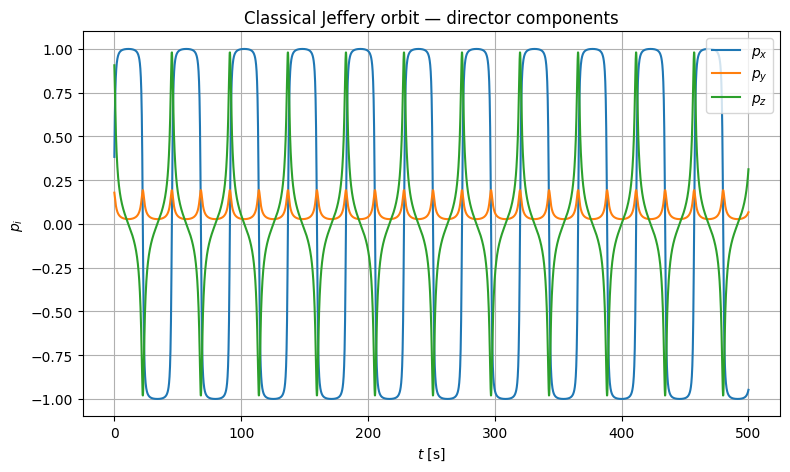

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    sol_jeffery.t,
    px,
    label=r"$p_x$"
)

plt.plot(
    sol_jeffery.t,
    py,
    label=r"$p_y$"
)

plt.plot(
    sol_jeffery.t,
    pz,
    label=r"$p_z$"
)

plt.xlabel(r"$t$ [s]")
plt.ylabel(r"$p_i$")

plt.title(
    "Classical Jeffery orbit — director components"
)

plt.grid(True)
plt.legend()

plt.show()

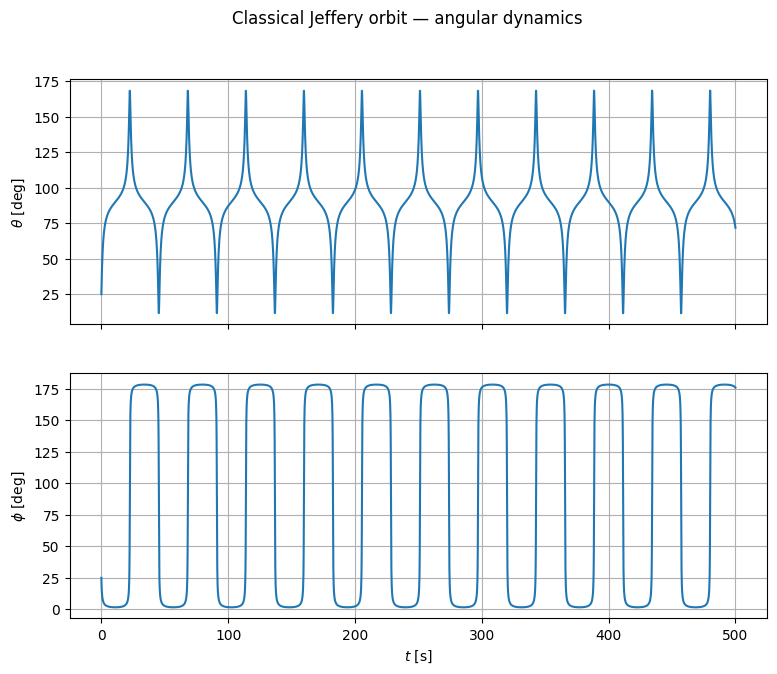

In [22]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True
)

ax[0].plot(
    sol_jeffery.t,
    theta_deg
)

ax[0].set_ylabel(
    r"$\theta$ [deg]"
)

ax[0].grid(True)

ax[1].plot(
    sol_jeffery.t,
    phi_deg
)

ax[1].set_xlabel(
    r"$t$ [s]"
)

ax[1].set_ylabel(
    r"$\phi$ [deg]"
)

ax[1].grid(True)

plt.suptitle(
    "Classical Jeffery orbit — angular dynamics"
)

plt.show()

In [23]:
import pyvista as pv
pv.set_jupyter_backend("server")
# ============================================================
# 3D REFERENCE GEOMETRY

plotter = pv.Plotter(
    window_size=(1100, 800)
)

plotter.set_background("white")

# Unit sphere S^2

sphere = pv.Sphere(
    radius=1.0,
    theta_resolution=80,
    phi_resolution=80
)

plotter.add_mesh(
    sphere,
    color="lightgray",
    opacity=0.22,
    smooth_shading=True,
    specular=0.15,
    show_edges=False
)


# ------------------------------------------------------------
# Initial particle orientation p0
# ------------------------------------------------------------

p0_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=p0,
    tip_length=0.22,
    tip_radius=0.05,
    shaft_radius=0.018,
    scale=0.98
)

plotter.add_mesh(
    p0_arrow,
    color="green"
)

p0_point = pv.PolyData(
    p0.reshape(1, 3)
)

plotter.add_mesh(
    p0_point,
    color="green",
    point_size=9,
    render_points_as_spheres=True
)


# Jeffery trajectory on S^2
trajectory = pv.Spline(
    P,
    P.shape[0]
)

plotter.add_mesh(
    trajectory,
    color="red",
    line_width=4
)

pf_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=pf,
    tip_length=0.22,
    tip_radius=0.05,
    shaft_radius=0.018,
    scale=0.98
)

plotter.add_mesh(
    pf_arrow,
    color="blue"
)

pf_point = pv.PolyData(
    pf.reshape(1, 3)
)

plotter.add_mesh(
    pf_point,
    color="blue",
    point_size=9,
    render_points_as_spheres=True
)

# ------------------------------------------------------------
# Background velocity field
# ------------------------------------------------------------

grid = np.linspace(-1.0, 1.0, 11)

points = []
vectors = []

for a_grid in grid:
    for b_grid in grid:

        if plane == "xy":
            X = np.array([
                a_grid,
                b_grid,
                0.0
            ])

        elif plane == "xz":
            X = np.array([
                a_grid,
                0.0,
                b_grid
            ])

        elif plane == "yz":
            X = np.array([
                0.0,
                a_grid,
                b_grid
            ])

        else:
            raise ValueError(
                "plane must be 'xy', 'xz' or 'yz'"
            )

        u = G @ X

        points.append(X)
        vectors.append(u)


points = np.asarray(points)
vectors = np.asarray(vectors)

flow_mesh = pv.PolyData(points)

flow_mesh["velocity"] = vectors

flow_glyphs = flow_mesh.glyph(
    orient="velocity",
    scale="velocity",
    factor=0.30
)

plotter.add_mesh(
    flow_glyphs,
    color="black",
    opacity=0.80
)


# ------------------------------------------------------------
# Axes and bounds
# ------------------------------------------------------------

plotter.add_axes(
    line_width=3,
    xlabel="x",
    ylabel="y",
    zlabel="z"
)

plotter.show_bounds(
    grid="front",
    location="outer",
    all_edges=True,
    color="black",
    xtitle="px",
    ytitle="py",
    ztitle="pz",
    font_size=18
)


# ------------------------------------------------------------
# Text
# ------------------------------------------------------------

if plane == "xy":

    flow_text = (
        f"u = ({gamma:g} y, 0, 0)"
    )

elif plane == "xz":

    flow_text = (
        f"u = ({gamma:g} z, 0, 0)"
    )

elif plane == "yz":

    flow_text = "simple shear in yz"


plotter.add_text(
    "Reference geometry on S^2\n"
    f"{flow_text}\n"
    f"c = {aspect_ratio:.3f}, beta = {beta:.3f}",
    position="upper_left",
    font_size=16,
    color="black"
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

plotter.add_legend(
    labels=[
        ["initial orientation p0", "green"],
        ["final orientation pf", "blue"],
        ["Jeffery orbit", "red"],
        ["background flow", "black"]
    ],
    bcolor="white",
    border=False,
    face="circle",
    size=(0.22, 0.18)
)


# ------------------------------------------------------------
# Camera
# ------------------------------------------------------------

plotter.camera_position = "iso"
plotter.camera.zoom(1.15)

plotter.show()

Widget(value='<iframe src="http://localhost:63640/index.html?ui=P_0x142923c40_1&reconnect=auto" class="pyvista…

In [24]:
# Particle semi-axes
a = Length / 2.0
b = diameter / 2.0

# Particle volume
Volume = (
    (4.0 / 3.0)
    * np.pi
    * a
    * b**2
)

# Scalar polarizability
alpha_scalar = jf.alpha(
    Volume,
    n_particle,
    n_medium
)

# Rayleigh range
zR = jf.rayleigh_range(
    w0,
    wavelength
)

# Trap depth
U0 = jf.trap_depth(
    alpha_scalar,
    laser_power,
    w0
)

# Harmonic stiffnesses
kx, ky, kz = jf.harmonic_stiffness_from_gaussian(
    U0,
    w0,
    zR
)

k_perp = 0.5 * (kx + ky)

print("a =", a, "m")
print("b =", b, "m")
print("Volume =", Volume, "m^3")

print()
print("zR =", zR, "m")
print("U0 =", U0, "J")

print()
print("kx =", kx, "N/m")
print("ky =", ky, "N/m")
print("kz =", kz, "N/m")
print("k_perp =", k_perp, "N/m")

a = 2.5e-05 m
b = 3.5e-06 m
Volume = 1.2828170002158321e-15 m^3

zR = 8.657366014854315e-06 m
U0 = 1.4091037978393881e-15 J

kx = 0.0015613338480214827 N/m
ky = 0.0015613338480214827 N/m
kz = 3.7601175586992064e-05 N/m
k_perp = 0.0015613338480214827 N/m


In [25]:
# ============================================================
# SECOND-MOMENT GRADIENT TORQUE STRENGTH
# ============================================================

kappa_grad_harmonic = (
    (a**2 - b**2)
    / 10.0
    * (k_perp - kz)
)

print(
    "kappa_grad_harmonic =",
    kappa_grad_harmonic,
    "J"
)

kappa_grad_harmonic = 9.336671950342341e-14 J


In [26]:
# ============================================================
# ROTATIONAL DRAG
# ============================================================

effective_radius = diameter / 2.0

rotational_drag = jf.rotational_drag_sphere(
    eta,
    effective_radius
)

xi_grad_harmonic = jf.alignment_rate_from_torque(
    kappa_grad_harmonic,
    rotational_drag
)

print(
    "rotational_drag =",
    rotational_drag,
    "N m s"
)

print(
    "xi_grad_harmonic =",
    xi_grad_harmonic,
    "1/s"
)

rotational_drag = 1.026920665012778e-18 N m s
xi_grad_harmonic = 181838.23285367747 1/s


In [27]:
# ============================================================
# JEFFERY + HARMONIC GRADIENT RHS
# ============================================================

def jeffery_harmonic_gradient_rhs(t, p):

    p = np.asarray(
        p,
        dtype=float
    )

    p = p / np.linalg.norm(p)

    # Hydrodynamic contribution
    p_dot_jeffery = jf.jeffery_rhs_vector(
        t,
        p,
        E,
        W,
        beta
    )

    # Harmonic gradient-alignment contribution
    p_dot_gradient = jf.uniaxial_alignment_drift(
        p,
        beam_axis,
        xi_grad_harmonic
    )

    return (
        p_dot_jeffery
        + p_dot_gradient
    )

In [28]:
# ============================================================
# INTEGRATION
# ============================================================

sol_harmonic = solve_ivp(
    fun=jeffery_harmonic_gradient_rhs,
    t_span=(t0, tf),
    y0=p0,
    t_eval=t_eval,
    rtol=rtol,
    atol=atol
)

if not sol_harmonic.success:
    raise RuntimeError(
        sol_harmonic.message
    )


P_harmonic_raw = sol_harmonic.y.T

norm_harmonic_raw = np.linalg.norm(
    P_harmonic_raw,
    axis=1
)

P_harmonic = jf.normalize_rows(
    P_harmonic_raw
)

px_harmonic = P_harmonic[:, 0]
py_harmonic = P_harmonic[:, 1]
pz_harmonic = P_harmonic[:, 2]

pf_harmonic = P_harmonic[-1]

print(
    "Final director =",
    pf_harmonic
)

print(
    "Maximum norm error =",
    np.max(
        np.abs(
            norm_harmonic_raw - 1.0
        )
    )
)

Final director = [5.39367786e-06 1.97992827e-13 1.00000000e+00]
Maximum norm error = 1.3458795966592163e-08


In [29]:
theta_harmonic_rad, phi_harmonic_wrapped, phi_harmonic_unwrapped = (
    jf.directors_to_angles(
        P_harmonic
    )
)

theta_harmonic_deg = np.rad2deg(
    theta_harmonic_rad
)

phi_harmonic_deg = np.rad2deg(
    phi_harmonic_unwrapped
)

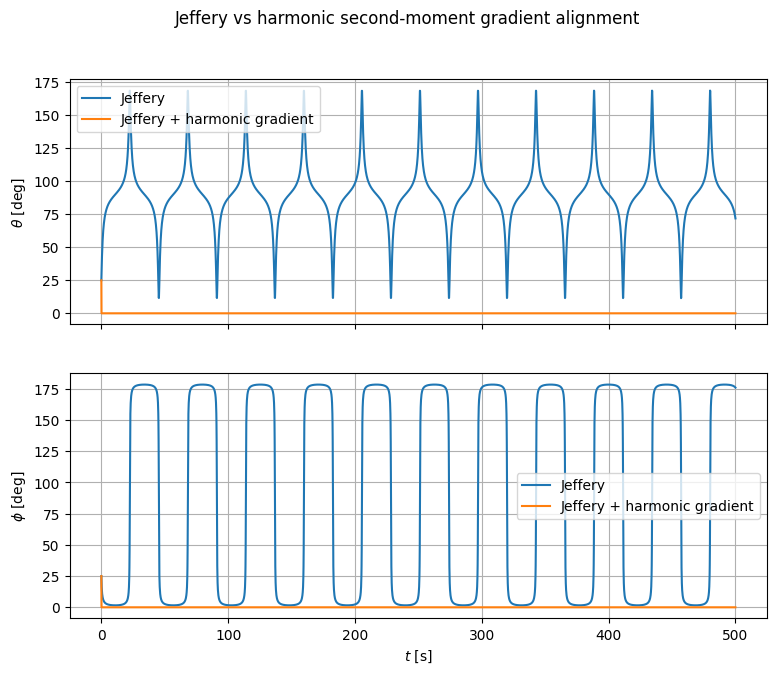

In [30]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True
)

# theta
ax[0].plot(
    sol_jeffery.t,
    theta_deg,
    label="Jeffery"
)

ax[0].plot(
    sol_harmonic.t,
    theta_harmonic_deg,
    label="Jeffery + harmonic gradient"
)

ax[0].set_ylabel(
    r"$\theta$ [deg]"
)

ax[0].grid(True)
ax[0].legend()


# phi
ax[1].plot(
    sol_jeffery.t,
    phi_deg,
    label="Jeffery"
)

ax[1].plot(
    sol_harmonic.t,
    phi_harmonic_deg,
    label="Jeffery + harmonic gradient"
)

ax[1].set_xlabel(
    r"$t$ [s]"
)

ax[1].set_ylabel(
    r"$\phi$ [deg]"
)

ax[1].grid(True)
ax[1].legend()


plt.suptitle(
    "Jeffery vs harmonic second-moment gradient alignment"
)

plt.show()

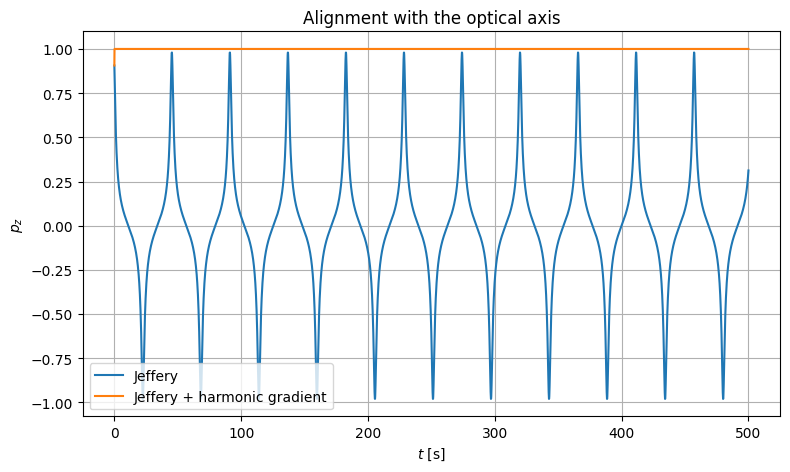

In [31]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    sol_jeffery.t,
    pz,
    label="Jeffery"
)

plt.plot(
    sol_harmonic.t,
    pz_harmonic,
    label="Jeffery + harmonic gradient"
)

plt.xlabel(
    r"$t$ [s]"
)

plt.ylabel(
    r"$p_z$"
)

plt.grid(True)
plt.legend()

plt.title(
    "Alignment with the optical axis"
)

plt.show()

In [32]:
p_dot_jeffery_0 = jf.jeffery_rhs_vector(
    0.0,
    p0,
    E,
    W,
    beta
)

p_dot_gradient_0 = jf.uniaxial_alignment_drift(
    p0,
    beam_axis,
    xi_grad_harmonic
)

print(
    "||p_dot_Jeffery(0)|| =",
    np.linalg.norm(p_dot_jeffery_0),
    "1/s"
)

print(
    "||p_dot_gradient(0)|| =",
    np.linalg.norm(p_dot_gradient_0),
    "1/s"
)

print(
    "xi_grad / gamma =",
    xi_grad_harmonic / gamma
)

||p_dot_Jeffery(0)|| = 0.823866611340437 1/s
||p_dot_gradient(0)|| = 69648.08391206722 1/s
xi_grad / gamma = 181838.23285367747


In [33]:
import pyvista as pv

pv.set_jupyter_backend("server")

# ============================================================
# 3D ORIENTATION COMPARISON
# Pure Jeffery vs Jeffery + harmonic second-moment torque
# ============================================================

plotter = pv.Plotter(
    window_size=(1100, 800)
)

plotter.set_background("white")


# ============================================================
# UNIT SPHERE S^2
# ============================================================

sphere = pv.Sphere(
    radius=1.0,
    theta_resolution=80,
    phi_resolution=80
)

plotter.add_mesh(
    sphere,
    color="lightgray",
    opacity=0.22,
    smooth_shading=True,
    specular=0.15,
    show_edges=False
)


# ============================================================
# INITIAL AND FINAL ORIENTATION
# Harmonic second-moment case
# ============================================================

p_initial = jf.normalize_vector(
    P_harmonic[0]
)

p_final_harmonic = jf.normalize_vector(
    P_harmonic[-1]
)


# ------------------------------------------------------------
# Initial orientation
# ------------------------------------------------------------

p0_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=p_initial,
    tip_length=0.22,
    tip_radius=0.05,
    shaft_radius=0.018,
    scale=0.98
)

plotter.add_mesh(
    p0_arrow,
    color="green"
)

p0_point = pv.PolyData(
    p_initial.reshape(1, 3)
)

plotter.add_mesh(
    p0_point,
    color="green",
    point_size=9,
    render_points_as_spheres=True
)


# ------------------------------------------------------------
# Final orientation: harmonic gradient case
# ------------------------------------------------------------

pf_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=p_final_harmonic,
    tip_length=0.22,
    tip_radius=0.05,
    shaft_radius=0.018,
    scale=0.98
)

plotter.add_mesh(
    pf_arrow,
    color="blue"
)

pf_point = pv.PolyData(
    p_final_harmonic.reshape(1, 3)
)

plotter.add_mesh(
    pf_point,
    color="blue",
    point_size=9,
    render_points_as_spheres=True
)


# ============================================================
# JEFFERY + HARMONIC SECOND-MOMENT TRAJECTORY
# ============================================================

harmonic_trajectory = pv.Spline(
    P_harmonic,
    P_harmonic.shape[0]
)

plotter.add_mesh(
    harmonic_trajectory,
    color="red",
    line_width=4
)


# ============================================================
# PURE JEFFERY REFERENCE ORBIT
# ============================================================

jeffery_trajectory = pv.Spline(
    P,
    P.shape[0]
)

plotter.add_mesh(
    jeffery_trajectory,
    color="orange",
    line_width=2,
    opacity=0.75
)


# ============================================================
# HARMONIC GRADIENT PREFERRED AXIS
# ============================================================

beam_axis_unit = (
    beam_axis
    / np.linalg.norm(beam_axis)
)

beam_axis_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=beam_axis_unit,
    tip_length=0.18,
    tip_radius=0.04,
    shaft_radius=0.012,
    scale=1.05
)

plotter.add_mesh(
    beam_axis_arrow,
    color="purple"
)


# Since the alignment is uniaxial, +z and -z are equivalent
minus_beam_axis_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=-beam_axis_unit,
    tip_length=0.18,
    tip_radius=0.04,
    shaft_radius=0.012,
    scale=1.05
)

plotter.add_mesh(
    minus_beam_axis_arrow,
    color="purple"
)


# ============================================================
# BACKGROUND SIMPLE-SHEAR FIELD
# Schematic reference only
# ============================================================

grid = np.linspace(
    -1.0,
    1.0,
    11
)

points = []
vectors = []

for a_grid in grid:
    for b_grid in grid:

        if plane == "xy":

            X = np.array([
                a_grid,
                b_grid,
                0.0
            ])

        elif plane == "xz":

            X = np.array([
                a_grid,
                0.0,
                b_grid
            ])

        else:

            raise ValueError(
                "plane must be 'xy' or 'xz'"
            )

        u = G @ X

        points.append(X)
        vectors.append(u)


points = np.asarray(points)
vectors = np.asarray(vectors)

flow_mesh = pv.PolyData(
    points
)

flow_mesh["velocity"] = vectors

flow_glyphs = flow_mesh.glyph(
    orient="velocity",
    scale="velocity",
    factor=0.30
)

plotter.add_mesh(
    flow_glyphs,
    color="black",
    opacity=0.65
)


# ============================================================
# AXES AND BOUNDS
# ============================================================

plotter.add_axes(
    line_width=3,
    xlabel="px",
    ylabel="py",
    zlabel="pz"
)

plotter.show_bounds(
    grid="front",
    location="outer",
    all_edges=True,
    color="black",
    xtitle="px",
    ytitle="py",
    ztitle="pz",
    font_size=18
)


# ============================================================
# TEXT
# ============================================================

if plane == "xy":

    flow_text = (
        f"u = ({gamma:g} y, 0, 0)"
    )

elif plane == "xz":

    flow_text = (
        f"u = ({gamma:g} z, 0, 0)"
    )


plotter.add_text(
    "Jeffery vs harmonic second-moment alignment\n"
    f"{flow_text}\n"
    f"aspect ratio = {aspect_ratio:.3f}, beta = {beta:.3f}\n"
    f"xi_grad = {xi_grad_harmonic:.3e} 1/s",
    position="upper_left",
    font_size=15,
    color="black"
)


# ============================================================
# LEGEND
# ============================================================

plotter.add_legend(
    labels=[
        ["initial orientation", "green"],
        ["final orientation (harmonic)", "blue"],
        ["Jeffery + harmonic gradient", "red"],
        ["pure Jeffery", "orange"],
        ["preferred optical axis", "purple"],
        ["background flow", "black"]
    ],
    bcolor="white",
    border=False,
    face="circle",
    size=(0.28, 0.22)
)


# ============================================================
# CAMERA
# ============================================================

plotter.camera_position = "iso"
plotter.camera.zoom(1.15)

plotter.show()

Widget(value='<iframe src="http://localhost:63640/index.html?ui=P_0x142886cd0_2&reconnect=auto" class="pyvista…

In [37]:
# ============================================================
# TRANSLATIONAL MOBILITY )Stokes de esfera, cambiart)
# ============================================================

effective_radius = diameter / 2.0

translational_mobility = 1.0 / (
    6.0
    * np.pi
    * eta
    * effective_radius
)

print(
    "Translational mobility =",
    translational_mobility,
    "m/(N s)"
)

Translational mobility = 15905155.957816955 m/(N s)


In [38]:
# ============================================================
# COUPLED HARMONIC MODEL
# R(t) + p(t)
# ============================================================

def coupled_harmonic_rhs(
    t,
    state,
    v_s
):

    state = np.asarray(
        state,
        dtype=float
    )

    R = state[0:3]

    p = state[3:6]
    p = p / np.linalg.norm(p)


    # ========================================================
    # TRANSLATION
    # ========================================================

    # Flow advection
    u_flow = G @ R

    # Harmonic optical force
    F_opt = jf.harmonic_com_force(
        R,
        kx,
        ky,
        kz
    )

    # Overdamped optical drift
    v_opt = jf.overdamped_translational_drift(
        F_opt,
        translational_mobility
    )

    # Active swimming
    v_swim = v_s * p

    # Total translational velocity
    R_dot = (
        u_flow
        + v_swim
        + v_opt
    )


    # ========================================================
    # ORIENTATION
    # ========================================================

    # Jeffery
    p_dot_jeffery = jf.jeffery_rhs_vector(
        t,
        p,
        E,
        W,
        beta
    )

    # Harmonic gradient alignment
    p_dot_gradient = jf.uniaxial_alignment_drift(
        p,
        beam_axis,
        xi_grad_harmonic
    )

    p_dot = (
        p_dot_jeffery
        + p_dot_gradient
    )


    return np.concatenate(
        (
            R_dot,
            p_dot
        )
    )

In [39]:
# ============================================================
# INITIAL STATE
# ============================================================

state0 = np.concatenate(
    (
        R0,
        p0
    )
)

In [40]:
# ============================================================
# PASSIVE PARTICLE
# ============================================================

sol_passive = solve_ivp(
    fun=lambda t, state: coupled_harmonic_rhs(
        t,
        state,
        0.0
    ),
    t_span=(t0, tf),
    y0=state0,
    t_eval=t_eval,
    rtol=rtol,
    atol=atol
)

if not sol_passive.success:
    raise RuntimeError(
        sol_passive.message
    )

In [41]:
# ============================================================
# ACTIVE PARTICLE
# ============================================================

sol_active = solve_ivp(
    fun=lambda t, state: coupled_harmonic_rhs(
        t,
        state,
        swimming_speed
    ),
    t_span=(t0, tf),
    y0=state0,
    t_eval=t_eval,
    rtol=rtol,
    atol=atol
)

if not sol_active.success:
    raise RuntimeError(
        sol_active.message
    )

In [42]:
# ============================================================
# EXTRACT RESULTS
# ============================================================

state_passive = sol_passive.y.T
state_active = sol_active.y.T


# Center-of-mass trajectories

R_passive = state_passive[:, 0:3]
R_active = state_active[:, 0:3]


# Orientation trajectories

P_passive_raw = state_passive[:, 3:6]
P_active_raw = state_active[:, 3:6]

P_passive = jf.normalize_rows(
    P_passive_raw
)

P_active = jf.normalize_rows(
    P_active_raw
)


theta_passive_rad, phi_passive_wrapped, phi_passive_unwrapped = (
    jf.directors_to_angles(
        P_passive
    )
)

theta_active_rad, phi_active_wrapped, phi_active_unwrapped = (
    jf.directors_to_angles(
        P_active
    )
)

theta_passive_deg = np.rad2deg(
    theta_passive_rad
)

theta_active_deg = np.rad2deg(
    theta_active_rad
)

phi_passive_deg = np.rad2deg(
    phi_passive_unwrapped
)

phi_active_deg = np.rad2deg(
    phi_active_unwrapped
)

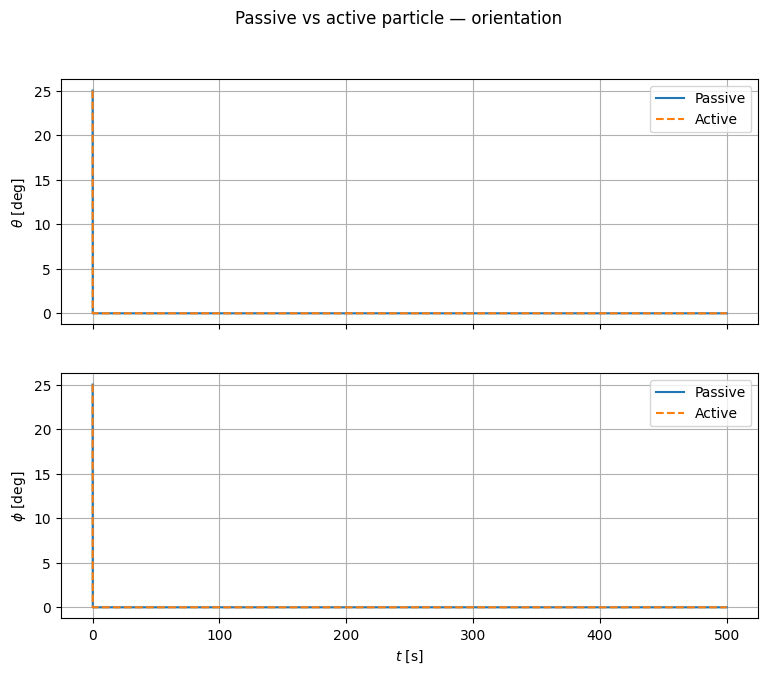

In [43]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True
)

# theta
ax[0].plot(
    sol_passive.t,
    theta_passive_deg,
    label="Passive"
)

ax[0].plot(
    sol_active.t,
    theta_active_deg,
    "--",
    label="Active"
)

ax[0].set_ylabel(
    r"$\theta$ [deg]"
)

ax[0].grid(True)
ax[0].legend()


# phi
ax[1].plot(
    sol_passive.t,
    phi_passive_deg,
    label="Passive"
)

ax[1].plot(
    sol_active.t,
    phi_active_deg,
    "--",
    label="Active"
)

ax[1].set_xlabel(
    r"$t$ [s]"
)

ax[1].set_ylabel(
    r"$\phi$ [deg]"
)

ax[1].grid(True)
ax[1].legend()

plt.suptitle(
    "Passive vs active particle — orientation"
)

plt.show()

In [45]:
# ============================================================
# ORIENTATION DIFFERENCE
# ============================================================

orientation_difference = np.linalg.norm(
    P_active - P_passive,
    axis=1
)

print(
    "Maximum active-passive orientation difference =",
    np.max(orientation_difference)
)

director_overlap = np.abs(
    np.sum(
        P_active * P_passive,
        axis=1
    )
)

print(
    "Minimum |p_active · p_passive| =",
    np.min(director_overlap)
)

Maximum active-passive orientation difference = 2.765584023773279e-16
Minimum |p_active · p_passive| = 0.9999999999999999


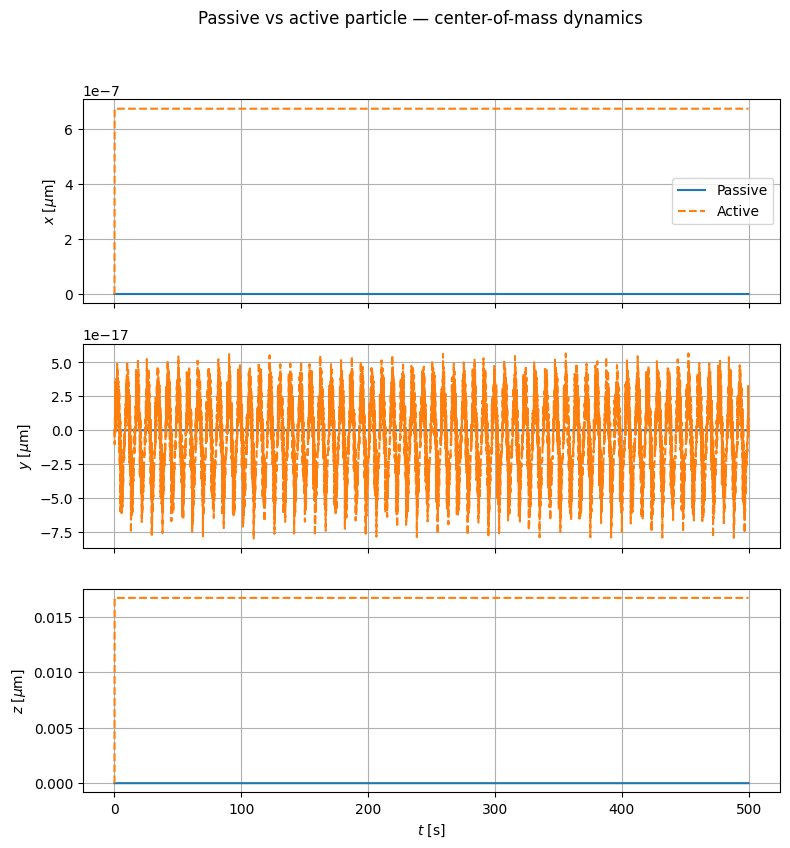

In [46]:
R_passive_um = (
    1.0e6
    * R_passive
)

R_active_um = (
    1.0e6
    * R_active
)

fig, ax = plt.subplots(
    3,
    1,
    figsize=(9, 9),
    sharex=True
)

labels = [
    r"$x$ [$\mu$m]",
    r"$y$ [$\mu$m]",
    r"$z$ [$\mu$m]"
]

for i in range(3):

    ax[i].plot(
        sol_passive.t,
        R_passive_um[:, i],
        label="Passive"
    )

    ax[i].plot(
        sol_active.t,
        R_active_um[:, i],
        "--",
        label="Active"
    )

    ax[i].set_ylabel(
        labels[i]
    )

    ax[i].grid(True)

ax[0].legend()

ax[2].set_xlabel(
    r"$t$ [s]"
)

plt.suptitle(
    "Passive vs active particle — center-of-mass dynamics"
)

plt.show()